# EDA - Campaign features (Member 3)

**Features:** `contact`, `month`, `day_of_week`, `campaign`, `pdays`, `previous`, `poutcome`  |  **Target:** `y` (term deposit subscription)

These seven columns describe *how the bank contacted the client*, in this campaign and in earlier ones. All of them are known **before** the next call is made, so none of them leaks the outcome (unlike `duration`, which is dropped).

**This notebook (part 1)** covers the four categorical features: `contact`, `poutcome`, `month`, `day_of_week`. Part 2 covers `campaign`, `pdays` and `previous`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2_contingency

# make `src` importable when the notebook runs from /notebooks
sys.path.append(str(Path.cwd().parent))
from src.config import RAW_DATA, TARGET, LEAKAGE_COLUMNS, ROOT
from src.data_cleaning import remove_duplicates, prepare_features_and_target

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, GREY, LIGHT = "#2a78d6", "#52514e", "#d9d8d2"     # bars / reference line / grid
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": LIGHT, "grid.linewidth": 0.6,
    "axes.grid.axis": "y",
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def save_fig(name):
    """Save the current figure into results/figures with the eda_campaign_ prefix."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"eda_campaign_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load data and basic structure

In [2]:
raw = pd.read_csv(RAW_DATA, sep=";")
print("Raw shape:", raw.shape)
print("Exact duplicate rows (all columns, incl. duration):", raw.duplicated().sum())

Raw shape: (41188, 21)
Exact duplicate rows (all columns, incl. duration): 12


**Order matters when removing duplicates.** We use the shared helpers from `src/data_cleaning.py`: remove exact duplicates *first*, then drop `duration`. The next cell shows why - if `duration` were dropped first, many *different* calls would look identical and be deleted by mistake.

In [3]:
print("Duplicates found BEFORE dropping duration:", raw.duplicated().sum())
print("Duplicates found AFTER dropping duration :", raw.drop(columns=LEAKAGE_COLUMNS).duplicated().sum(),
      " <- these are different calls (different duration), not real duplicates")

clean = remove_duplicates(raw)
X, y = prepare_features_and_target(clean)            # drops the target and duration from the predictors
df = X.assign(y=(y == "yes").astype(int))            # y = 1 means the client subscribed

CAMPAIGN_COLS = ["contact", "month", "day_of_week", "campaign", "pdays", "previous", "poutcome"]
overall = df["y"].mean()
print(f"\nClean shape: {df.shape}   subscribers: {df['y'].sum():,}   overall subscription rate: {overall:.2%}")

Duplicates found BEFORE dropping duration: 12
Duplicates found AFTER dropping duration : 1784  <- these are different calls (different duration), not real duplicates

Clean shape: (41176, 20)   subscribers: 4,639   overall subscription rate: 11.27%


In [4]:
summary = pd.DataFrame({
    "dtype": df[CAMPAIGN_COLS].dtypes.astype(str),
    "unique values": df[CAMPAIGN_COLS].nunique(),
    "missing": df[CAMPAIGN_COLS].isna().sum(),
    "'unknown' coded": (df[CAMPAIGN_COLS] == "unknown").sum(),
})
summary

,dtype,unique values,missing,'unknown' coded
contact,object,2,0,0
month,object,10,0,0
day_of_week,object,5,0,0
campaign,int64,42,0,0
pdays,int64,27,0,0
previous,int64,8,0,0
poutcome,object,3,0,0


### Insight -> decision

- Finding: 41,176 clients remain after removing the **12** true duplicates (the same number as in our dataset proposal). The 7 campaign columns have **no missing values and no 'unknown' codes**.
- Decision: remove duplicates before dropping `duration`, using `remove_duplicates` from `src/data_cleaning.py`.
- Reason / alternative rejected: dropping `duration` first would delete 1,784 rows that are different calls, not duplicates.

## 2. Helpers

Every categorical feature gets the same treatment: a table of customers and subscription rate, and a bar chart with the overall rate (dashed line) as reference. The customer count is written under each category, so small groups are visible.

In [5]:
def rate_table(col, order=None):
    """Customers and subscription rate for each value of `col`."""
    t = df.groupby(col, observed=True)["y"].agg(customers="size", subscription_rate="mean")
    t["lift_vs_overall"] = t["subscription_rate"] / overall
    return t if order is None else t.loc[order]


def rate_bar(t, title, name, xlabel, figsize=(6.5, 4)):
    """Bar chart of subscription rate; dashed line = overall rate; n under each label."""
    fig, ax = plt.subplots(figsize=figsize)
    labels = [f"{i}\n(n={n:,})" for i, n in zip(t.index, t["customers"])]
    bars = ax.bar(labels, t["subscription_rate"] * 100, color=BLUE, width=0.6)
    ax.axhline(overall * 100, color=GREY, linestyle="--", linewidth=1.2, label=f"overall rate {overall:.1%}")
    ax.legend(loc="upper right", frameon=False)
    for b, r in zip(bars, t["subscription_rate"]):
        ax.annotate(f"{r:.1%}", (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=10, zorder=5,
                    bbox=dict(facecolor="white", edgecolor="none", pad=1))
    ax.set_ylabel("Subscription rate (%)")
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylim(0, t["subscription_rate"].max() * 100 * 1.3)
    save_fig(name)

## 3. `contact` - how the client was reached

In [6]:
t = rate_table("contact")
t

,customers,subscription_rate,lift_vs_overall
contact,,,
cellular,26135,0.147,1.308
telephone,15041,0.052,0.464


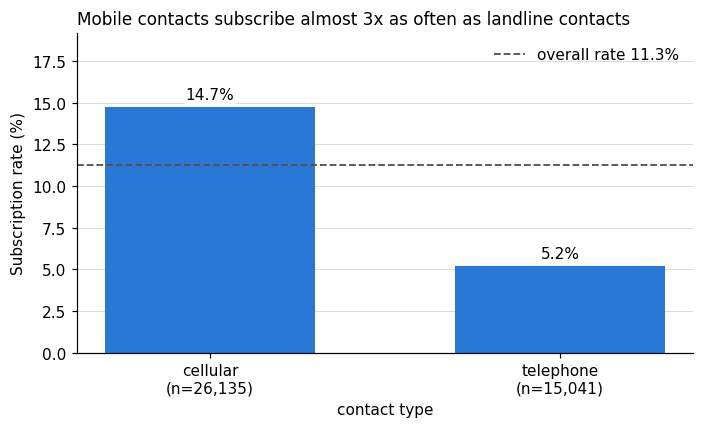

In [7]:
rate_bar(t, "Mobile contacts subscribe almost 3x as often as landline contacts", "contact_rate", "contact type")

The next cell checks whether `contact` could be hiding something else. The file is ordered by date, so we split the rows into five equal blocks (oldest to newest) and look at the share of mobile contacts and the overall subscription rate in each.

In [8]:
block = pd.cut(np.arange(len(df)), 5, labels=["1st (oldest)", "2nd", "3rd", "4th", "5th (newest)"])
by_block = df.groupby(block, observed=True)
pd.DataFrame({
    "share cellular": by_block["contact"].apply(lambda s: (s == "cellular").mean()),
    "overall subscription rate": by_block["y"].mean(),
})

,share cellular,overall subscription rate
1st (oldest),0.000,0.031
2nd,0.447,0.054
3rd,0.919,0.059
4th,0.928,0.111
5th (newest),0.880,0.308


### Insight -> decision

- Finding: **cellular 14.7%** (26,135 clients) vs **telephone 5.2%** (15,041 clients), about 2.8 times higher. In the oldest fifth of the file *every* call was to a landline, so contact type and time period are mixed together.
- Decision: keep `contact` and one-hot encode it (2 categories, no missing values).
- Reason / caution: the gap is large, but part of it may be a time effect (mobile numbers were used later in the file, and the overall subscription rate also rises from block to block). We describe it as a strong pattern, not proof that mobile numbers cause subscriptions.

## 4. `poutcome` - result of the previous campaign

In [9]:
t = rate_table("poutcome", order=["success", "failure", "nonexistent"])
t

,customers,subscription_rate,lift_vs_overall
poutcome,,,
success,1373,0.651,5.779
failure,4252,0.142,1.263
nonexistent,35551,0.088,0.784


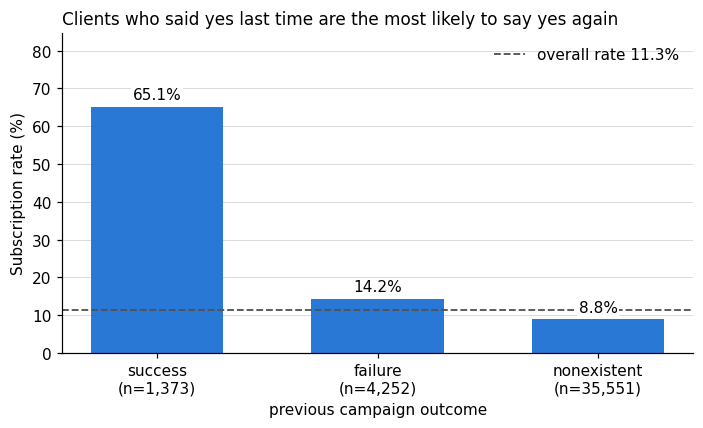

In [10]:
rate_bar(t, "Clients who said yes last time are the most likely to say yes again", "poutcome_rate", "previous campaign outcome")

### Insight -> decision

- Finding: **success 65.1%**, failure 14.2%, nonexistent (never contacted before) 8.8%. A previous success is about **5.8 times** the overall rate of 11.3% - the strongest single signal in our feature group. But only 1,373 clients (3.3%) are previous successes, so it is a strong signal on a narrow group.
- Decision: keep `poutcome` and one-hot encode it.
- Reason: strongest predictor, three clear categories, no missing values.

## 5. `month` - month of the last contact

In [11]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]   # calendar order (no jan/feb in the data)
t = rate_table("month", order=month_order)
t["share_of_all_calls"] = t["customers"] / len(df)
t

,customers,subscription_rate,lift_vs_overall,share_of_all_calls
month,,,,
mar,546,0.505,4.487,0.013
apr,2631,0.205,1.818,0.064
may,13767,0.064,0.571,0.334
jun,5318,0.105,0.933,0.129
jul,7169,0.090,0.802,0.174
aug,6176,0.106,0.941,0.150
sep,570,0.449,3.986,0.014
oct,717,0.439,3.900,0.017
nov,4100,0.101,0.901,0.100


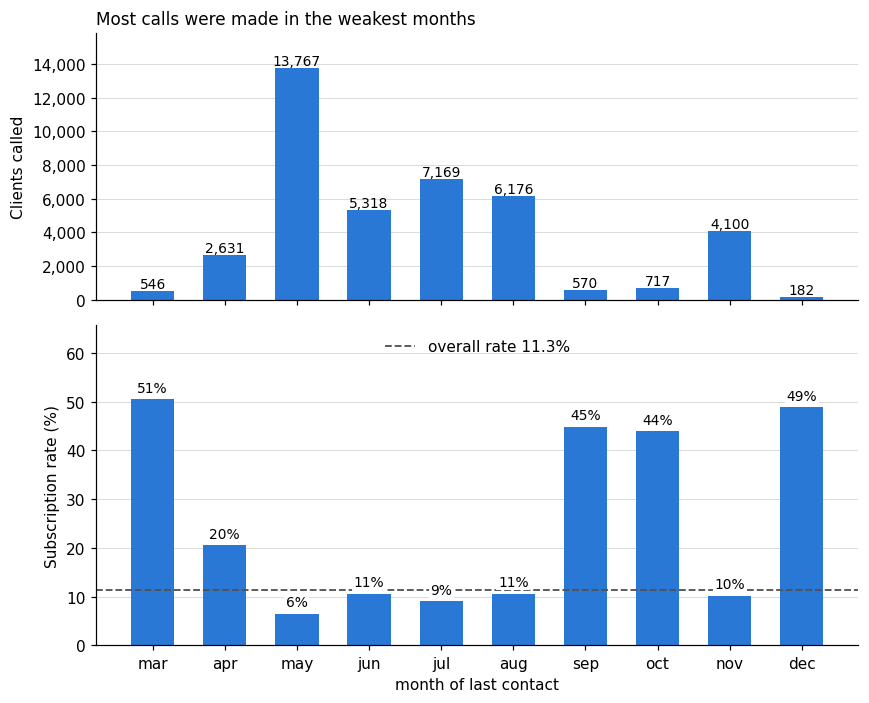

In [12]:
# Two panels with the same x-axis (volume on top, rate below) instead of one chart with two y-axes.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]})

ax1.bar(t.index, t["customers"], color=BLUE, width=0.6)
for x, n in zip(t.index, t["customers"]):
    ax1.text(x, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("Clients called")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.set_ylim(0, t["customers"].max() * 1.15)
ax1.set_title("Most calls were made in the weakest months", loc="left", fontsize=11)

ax2.bar(t.index, t["subscription_rate"] * 100, color=BLUE, width=0.6)
ax2.axhline(overall * 100, color=GREY, linestyle="--", linewidth=1.2, label=f"overall rate {overall:.1%}")
ax2.legend(loc="upper center", frameon=False)
for x, r in zip(t.index, t["subscription_rate"]):
    ax2.annotate(f"{r:.0%}", (x, r * 100), xytext=(0, 3), textcoords="offset points", ha="center",
                 va="bottom", fontsize=9, zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax2.set_ylabel("Subscription rate (%)")
ax2.set_xlabel("month of last contact")
ax2.set_ylim(0, t["subscription_rate"].max() * 100 * 1.3)
save_fig("month_volume_and_rate")

### Insight -> decision

- Finding: **May holds one third of all calls (33.4%) and has the lowest rate (6.4%)**. March, September, October and December convert at **44-51%**, but together they are only 2,015 calls (4.9%). April is in between (20.5%). There is no January or February in the data.
- Decision: keep `month` and one-hot encode it.
- Reason / caution: the differences are large, so the model should use them. The small months may reflect *who* was called then (for example, follow-ups of earlier successes), so this is a pattern worth testing in a future campaign, not proof that March itself causes subscriptions. `month` is also a partial stand-in for time, which matters for the chronological test split.

## 6. `day_of_week` - weekday of the last contact

In [13]:
t = rate_table("day_of_week", order=["mon", "tue", "wed", "thu", "fri"])
t

,customers,subscription_rate,lift_vs_overall
day_of_week,,,
mon,8512,0.100,0.883
tue,8086,0.118,1.046
wed,8134,0.117,1.036
thu,8618,0.121,1.075
fri,7826,0.108,0.960


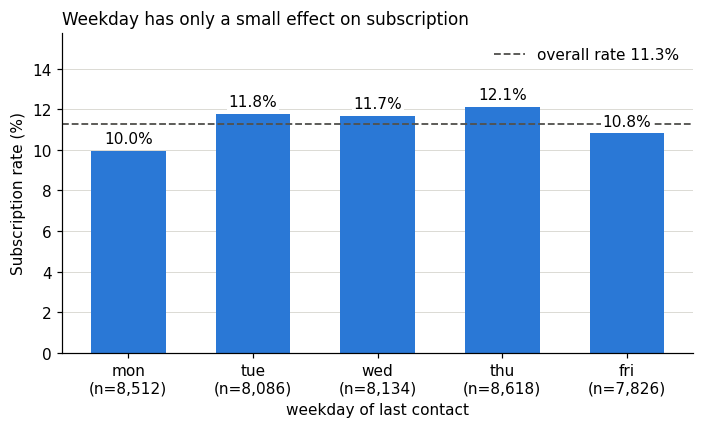

In [14]:
rate_bar(t, "Weekday has only a small effect on subscription", "day_of_week_rate", "weekday of last contact")

### Insight -> decision

- Finding: rates range only from **10.0% (Monday) to 12.1% (Thursday)** - about 2 percentage points, with 7,800-8,600 clients on each day.
- Decision: keep `day_of_week` for now (cheap to encode); Member 4's feature-selection step can test dropping it.
- Reason: a weak feature is still a useful result. It tells the bank that the calling day matters much less than contact type, month or customer history.

## 7. How strong is each feature? (chi-square and Cramer's V)

A chi-square test asks whether a feature and `y` are independent. With 41,000 rows even tiny differences are "significant", so the p-value alone is not enough. **Cramer's V** (0 = no link, 1 = perfect link) shows the *strength* of the link.

In [15]:
def cramers_v(col):
    ct = pd.crosstab(df[col], df["y"])
    chi2, p, _, _ = chi2_contingency(ct)
    return pd.Series({"chi2": chi2, "p_value": p, "cramers_v": np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))})

strength = pd.DataFrame({c: cramers_v(c) for c in ["poutcome", "month", "contact", "day_of_week"]}).T
strength.sort_values("cramers_v", ascending=False)

,chi2,p_value,cramers_v
poutcome,"4,230.143",0.000,0.321
month,"3,103.033",0.000,0.275
contact,862.081,0.000,0.145
day_of_week,26.054,0.000,0.025


### Insight -> decision

- Finding: strength of link with `y` (Cramer's V): **`poutcome` 0.32 > `month` 0.28 > `contact` 0.15 >> `day_of_week` 0.025**. All four p-values are below 0.001, but for `day_of_week` that only reflects the large sample - the effect itself is negligible.
- Decision: `poutcome`, `month` and `contact` are the key categorical signals in this group; `day_of_week` is the first candidate to drop in feature selection.
- Reason: this ranking agrees with the bar charts above, so the numbers and the pictures tell the same story.

### Part 1 summary

| Feature | Subscription pattern | Decision |
|---|---|---|
| `poutcome` | success 65.1% vs 8.8% never contacted | keep, one-hot encode |
| `month` | 6.4% (May) to 50.5% (March) | keep, one-hot encode |
| `contact` | cellular 14.7% vs telephone 5.2% | keep, one-hot encode |
| `day_of_week` | 10.0% to 12.1% | keep for now; Member 4 may drop it |

*Part 2 (next): `campaign` outliers, and `pdays` / `previous`, including the `pdays = 999` inconsistency.*